In [62]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error

In [4]:
insurance_data = pd.read_csv("datasets/insurance.csv")
insurance = insurance_data.copy()

<Axes: xlabel='bmi', ylabel='charges'>

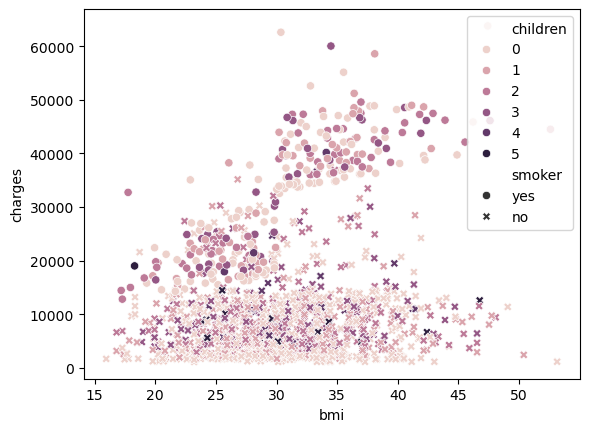

In [5]:
sns.scatterplot(data=insurance, x="bmi", y="charges", style="smoker", hue="children")

In [6]:
X = insurance.drop(columns=["charges"], axis=1)
y = insurance["charges"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

In [8]:
X_train

,age,sex,bmi,children,smoker,region
560,46,female,19.950,2,no,northwest
1285,47,female,24.320,0,no,northeast
1142,52,female,24.860,0,no,southeast
969,39,female,34.320,5,no,southeast
486,54,female,21.470,3,no,northwest
...,...,...,...,...,...,...
1095,18,female,31.350,4,no,northeast
1130,39,female,23.870,5,no,southeast
1294,58,male,25.175,0,no,northeast
860,37,female,47.600,2,yes,southwest


In [9]:
# encoding
le = LabelEncoder()
X_train["sex"] = le.fit_transform(X_train["sex"])
X_train["smoker"] = le.fit_transform(X_train["smoker"])
X_test["sex"] = le.fit_transform(X_test["sex"])
X_test["smoker"] = le.fit_transform(X_test["smoker"])
ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
ohe.fit(X_train[["region"]])
X_train_region = ohe.transform(X_train[["region"]])
X_train = pd.concat([X_train, X_train_region], axis=1).drop(["region"], axis=1)
X_test_region = ohe.transform(X_test[["region"]])
X_test = pd.concat([X_test, X_test_region], axis=1).drop(["region"], axis=1)

In [10]:
# feature engineering
# new features
def assign_weight(bmi):
    if bmi < 18:
        return 0
    elif bmi <= 25:
        return 1
    else:
        return 2
X_train["weight"] = X_train["bmi"].map(lambda weight: assign_weight(weight))
X_test["weight"] = X_test["bmi"].map(lambda weight: assign_weight(weight))
X_train =  X_train.assign(bmi_smoker = X_train["smoker"] * X_train["bmi"])
X_test =  X_test.assign(bmi_smoker = X_test["smoker"] * X_test["bmi"])

In [11]:
X_train

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,weight,bmi_smoker
560,46,0,19.950,2,0,0.0,1.0,0.0,0.0,1,0.0
1285,47,0,24.320,0,0,1.0,0.0,0.0,0.0,1,0.0
1142,52,0,24.860,0,0,0.0,0.0,1.0,0.0,1,0.0
969,39,0,34.320,5,0,0.0,0.0,1.0,0.0,2,0.0
486,54,0,21.470,3,0,0.0,1.0,0.0,0.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1095,18,0,31.350,4,0,1.0,0.0,0.0,0.0,2,0.0
1130,39,0,23.870,5,0,0.0,0.0,1.0,0.0,1,0.0
1294,58,1,25.175,0,0,1.0,0.0,0.0,0.0,2,0.0
860,37,0,47.600,2,1,0.0,0.0,0.0,1.0,2,47.6


MSE at 0.001 = 20926419.546953786
MSE at 0.1 = 20925773.160531413
MSE at 0.5 = 20923199.275492582
MSE at 1 = 20920102.487325083
MSE at 2 = 20914319.976270955
MSE at 3 = 20909102.473407485
MSE at 4 = 20904404.744916078
MSE at 5 = 20900263.351524003
MSE at 6 = 20896666.338284884
MSE at 7 = 20893629.98624563
MSE at 8 = 20891166.81818454
MSE at 10 = 20887927.241896182
MSE at 20 = 20903802.992952276
MSE at 30 = 20964180.05515153
MSE at 40 = 21066565.495887145
MSE at 50 = 21175316.882519707


<Axes: >

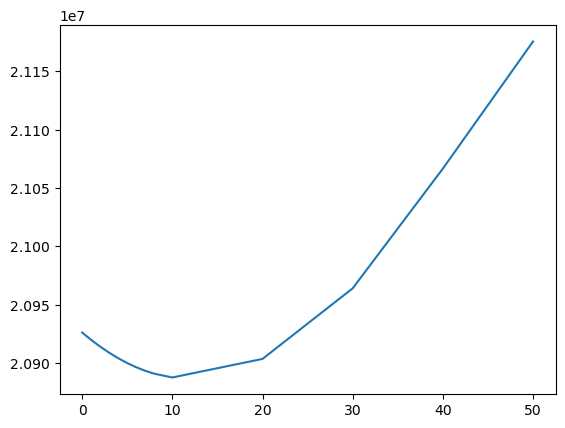

In [43]:

alphas = [0.001, 0.1, 0.5, 1,2,3,4, 5,6,7,8, 10, 20, 30, 40, 50]
mses = []

for alpha in alphas:
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)
    y_test_predicted = model.predict(X_test)
    mse = mean_squared_error(y_test, y_test_predicted)
    mses.append(mse)
    print("MSE at", alpha, "=", mse) 


sns.lineplot(x=alphas, y=mses)

In [59]:
alphas = [0.001, 0.1, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 10, 20, 30, 40, 50]
model = LassoCV(alphas = alphas, cv = 10, max_iter=1000)
model.fit(X_train, y_train)
y_test_predicted = model.predict(X_test)
mse = mean_squared_error(y_test, y_test_predicted)
print("MSE at", model.alpha_, "=", mse) 

MSE at 3.0 = 20909102.473407485


In [53]:
alpha=0.1
model = Ridge(alpha=alpha)
model.fit(X_train, y_train)
y_test_predicted = model.predict(X_test)
mse = mean_squared_error(y_test, y_test_predicted)
print("MSE at", alpha ,"is: ", mse)

MSE at 0.1 is:  20910522.60926203


In [56]:
model = RidgeCV(alphas=alphas)
model.fit(X_train, y_train)
y_test_predicted = model.predict(X_test)
mse = mean_squared_error(y_test, y_test_predicted)
print("MSE at", model.alpha_, "=", mse) 

MSE at 0.1 = 20910522.608401462


In [66]:
model = ElasticNetCV(alphas=alphas, l1_ratio=0.5, max_iter=10000)
model.fit(X_train, y_train)
y_test_predicted = model.predict(X_test)
mse = mean_squared_error(y_test, y_test_predicted)
print("MSE at", model.alpha_, "=", mse) 

MSE at 0.001 = 20859938.329263445


In [50]:
r2 = r2_score(y_test, y_test_predicted)
n, k = X_test.shape
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print("R2:", r2)
print("Adjusted R2:", adjusted_r2)

R2: 0.8656155054858071
Adjusted R2: 0.8598411717371504
